OUTLIER DETECTION USING Z-SCORE AND INTERQUARTILE RANGE

In [110]:
import mysql.connector
import configparser
import pandas as pd
from scipy.stats import iqr
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#Location of the ini file
config = configparser.ConfigParser()
config.read('C:\\Users\\svi02\\.spyder-py3\\erfpPROD.ini')

['C:\\Users\\svi02\\.spyder-py3\\erfpPROD.ini']

In [111]:
host=config['erfpPROD']['host']
user=config['erfpPROD']['user']
pwd=config['erfpPROD']['pwd']
database=config['erfpPROD']['database']

In [112]:
conn = mysql.connector.connect(
          host=host,
          user=user,
          passwd=pwd,
          database=database)
cursor = conn.cursor()

In [113]:
import_query_location = 'C:\\Users\\svi02\\Documents\\Green_score\\NORMALISED\\CSR_CARBON.sql' 
import_query_open = open(import_query_location, 'r', encoding="utf8")
import_query_read = import_query_open.read()

In [114]:
sql_select_query = """SELECT 
        H.HOTEL_ID_VALUE AS HOTEL_ID
       ,H.HOTEL_NAME_NAME AS HOTEL_NAME   
       ,MEAS_ENERGY
       ,MEAS_ENERGY_AMT
       ,MEAS_ENERGY_UOM
       ,MEAS_ENERGY_PD 
       FROM GBTA_HOTEL_RFP.GBTA_ANSWERS_FOR_OFFER ANS
JOIN SOURCING.BI_ERFP_RFPENTITY RFP ON RFP.ID_VALUE = ANS.RFP_ID
JOIN SOURCING.BI_ERFP_HOTEL_FOR_RFPENTITY H ON RFP.ID_VALUE = H.OR_RFP_VALUE AND H.HOTEL_ID_VALUE = ANS.HOTEL_ID
WHERE 
      MEAS_ENERGY IS TRUE
   AND (MEAS_ENERGY_AMT IS NOT NULL OR MEAS_ENERGY_AMT <> 0)
   AND (MEAS_ENERGY_PD IS NOT NULL OR MEAS_ENERGY_PD <> 0) 
   AND MEAS_ENERGY_UOM LIKE 'BTU per Square Foot'"""

cursor.execute(import_query_read)

QUERY = cursor.fetchall()
print('Total Row(s):', cursor.rowcount)

# Importing data into a DataFrame
import pandas as pd
erfp_df = pd.DataFrame()
a=[]
for row in QUERY:
        a.append(row)

erfp_df = pd.DataFrame(a)
df_col_names =  [i[0] for i in cursor.description]
erfp_df.columns = df_col_names

Total Row(s): 6983


In [115]:
erfp_df.head()

,HOTEL_ID,MEAS_CARBON,MEAS_CARBON_AMT,MEAS_CARBON_UOM_NORMALISED,MEAS_CARBON_AMT_LBS,MEAS_CARBON_PD,MAX_LATEST_DATE
0,6,1,15.50,KILOGRAMS,34.172,12,2019-09-06 23:35:07
1,7,1,22.20,KILOGRAMS,48.943,12,2019-09-07 08:52:41
2,18,1,9999.00,KILOGRAMS,22043.995,12,2019-09-06 15:24:18
3,48,1,17.00,KILOGRAMS,37.479,12,2019-09-06 07:03:30
4,75,1,15.90,KILOGRAMS,35.053,12,2019-09-06 23:35:07


In [116]:
erfp_df.MEAS_CARBON_AMT_LBS = pd.to_numeric(erfp_df.MEAS_CARBON_AMT_LBS)
erfp_df.dtypes

HOTEL_ID                               int64
MEAS_CARBON                            int64
MEAS_CARBON_AMT                       object
MEAS_CARBON_UOM_NORMALISED            object
MEAS_CARBON_AMT_LBS                  float64
MEAS_CARBON_PD                         int64
MAX_LATEST_DATE               datetime64[ns]
dtype: object

In [117]:
# MEAS_ENERGY_AMT = erfp_df.MEAS_ENERGY_AMT.to_numpy()
# #iqr(MEAS_ENERGY_AMT)
# MEAS_ENERGY_AMT

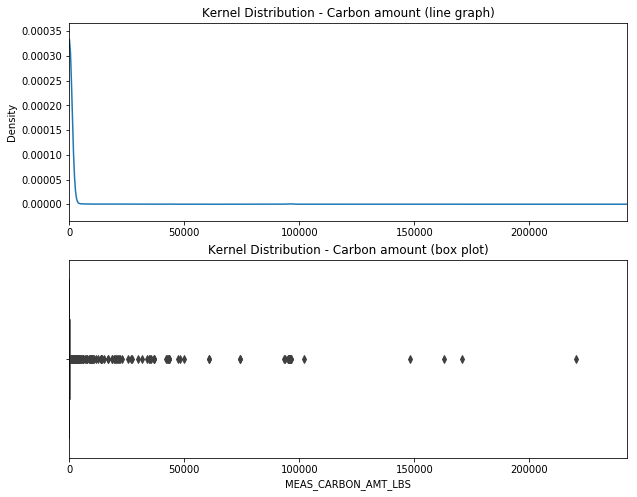

In [118]:
# Visualising to FIND the outliers

i = 'MEAS_CARBON_AMT_LBS'
 
plt.figure(figsize=(10,8))
plt.subplot(211)
plt.xlim(erfp_df[i].min()*1.5, erfp_df[i].max()*1.1)
plt.title("Kernel Distribution - Carbon amount (line graph)") 
ax = erfp_df[i].plot(kind='kde').margins(0.1)
 
plt.subplot(212)
plt.xlim(erfp_df[i].min()*1.5, erfp_df[i].max()*1.1)
plt.title("Kernel Distribution - Carbon amount (box plot)") 
sns.boxplot(x=erfp_df[i])

In [119]:
# Remove any zeros (otherwise we get (-inf)
erfp_df.loc[erfp_df.MEAS_CARBON_AMT_LBS == 0, 'MEAS_CARBON_AMT_LBS'] = np.nan
erfp_df.loc[erfp_df.MEAS_CARBON_AMT_LBS == 9999, 'MEAS_CARBON_AMT_LBS'] = np.nan
erfp_df.loc[erfp_df.MEAS_CARBON_AMT_LBS == 9999.99, 'MEAS_CARBON_AMT_LBS'] = np.nan
 
# Drop NA
erfp_df.dropna(inplace=True)

erfp_df.shape

(6981, 7)

Text(0.5,1,'Kernel Distribution of Log transfomed values - Carbon amount (box graph)')

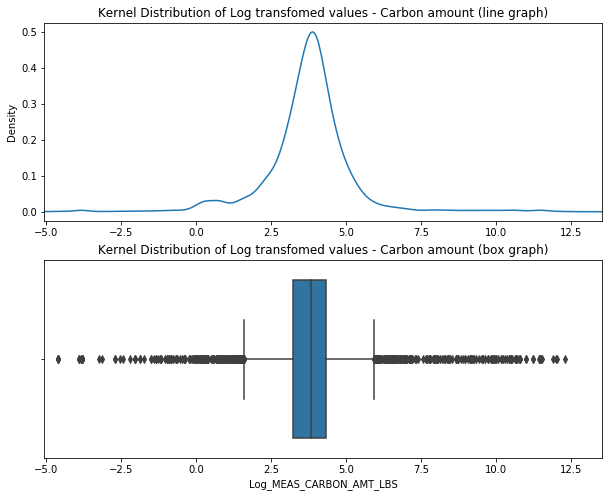

In [120]:
# Visualising Log Transform
erfp_df['Log_' + i] = np.log(erfp_df[i])

i = 'Log_MEAS_CARBON_AMT_LBS'
 
plt.figure(figsize=(10,8))
plt.subplot(211)
plt.xlim(erfp_df[i].min()*1.1, erfp_df[i].max()*1.1)
plt.title("Kernel Distribution of Log transfomed values - Carbon amount (line graph)") 

ax = erfp_df[i].plot(kind='kde')
 
plt.subplot(212)
plt.xlim(erfp_df[i].min()*1.1, erfp_df[i].max()*1.1)
sns.boxplot(x=erfp_df[i])
plt.title("Kernel Distribution of Log transfomed values - Carbon amount (box graph)")

In [122]:
# OUTLIER DETECTION USING Z -SCORE
i = 'MEAS_CARBON_AMT_LBS'
_mean = erfp_df[i].mean()
_std = erfp_df[i].std()

erfp_df[i + '_Zscore'] = (erfp_df[i] - _mean)/(_std)
erfp_df[i + '_Zscore_abs'] = erfp_df[i + '_Zscore'].apply(np.abs)

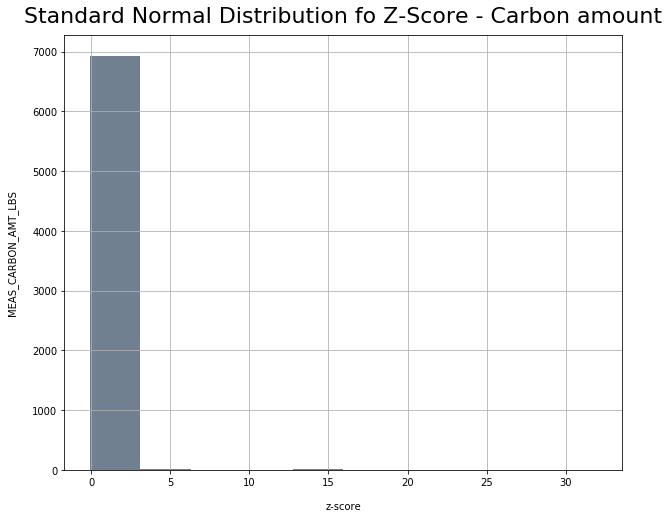

In [123]:
plt.subplots(figsize=(10,8))
erfp_df[i + '_Zscore'].hist(color='slategray')
plt.title("Standard Normal Distribution fo Z-Score - Carbon amount", y=1.015, fontsize=22)
plt.xlabel("z-score", labelpad=14)
plt.ylabel(i, labelpad=14);

In [124]:
erfp_df['MEAS_CARBON_AMT_LBS_Zscore_abs'].min()

0.0002951525697171838

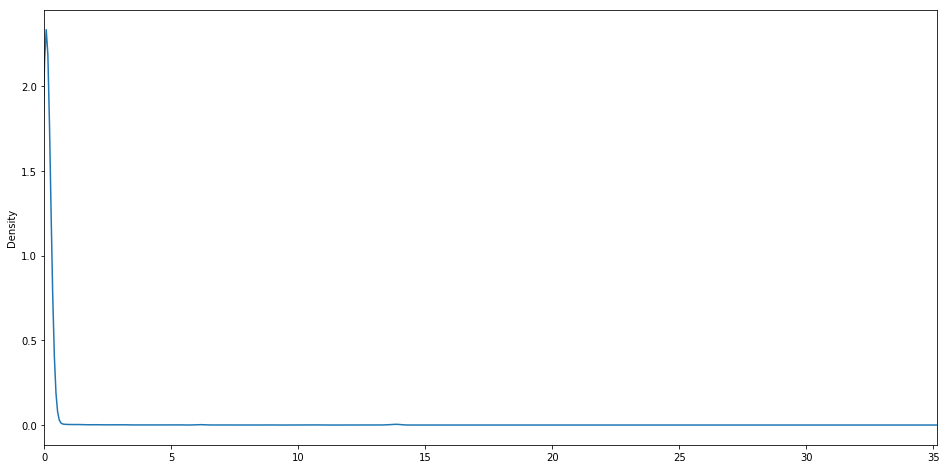

In [125]:
# erfp_df['MEAS_CARBON_AMT_LBS_Zscore_abs']
# # Visualising Log Transform
# erfp_df['Log_' + i] = np.log(erfp_df[i])

i = 'MEAS_CARBON_AMT_LBS_Zscore_abs'
 
plt.figure(figsize=(10,8))
plt.subplots(figsize=(16,8))
plt.xlim(erfp_df[i].min()*1.1, erfp_df[i].max()*1.1)
 
ax = erfp_df[i].plot(kind='kde')

In [126]:
erfp_df[erfp_df.MEAS_CARBON_AMT_LBS_Zscore_abs > 3].count()

HOTEL_ID                          49
MEAS_CARBON                       49
MEAS_CARBON_AMT                   49
MEAS_CARBON_UOM_NORMALISED        49
MEAS_CARBON_AMT_LBS               49
MEAS_CARBON_PD                    49
MAX_LATEST_DATE                   49
Log_MEAS_CARBON_AMT_LBS           49
MEAS_CARBON_AMT_LBS_Zscore        49
MEAS_CARBON_AMT_LBS_Zscore_abs    49
dtype: int64

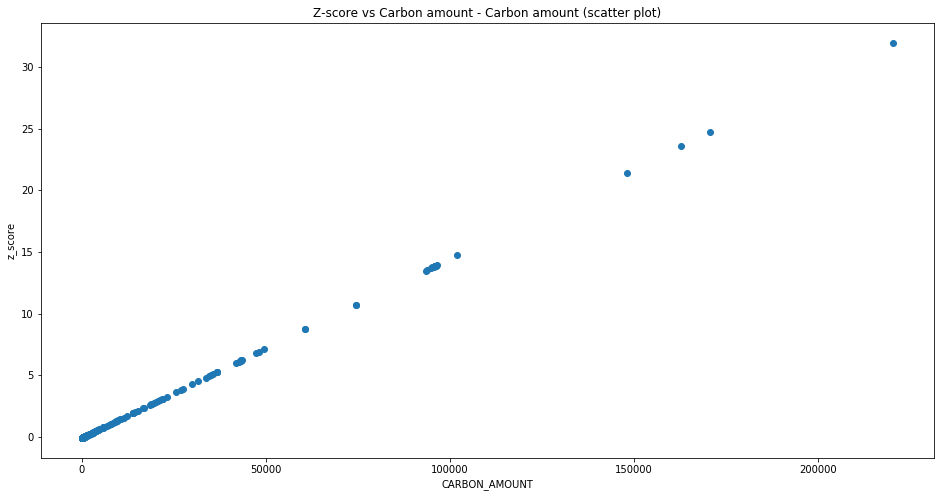

In [127]:
fig, ax = plt.subplots(figsize=(16,8))
ax.scatter(erfp_df['MEAS_CARBON_AMT_LBS'], erfp_df['MEAS_CARBON_AMT_LBS_Zscore'])
ax.set_xlabel('CARBON_AMOUNT')
ax.set_ylabel('z_score')
plt.title("Z-score vs Carbon amount - Carbon amount (scatter plot)") 
plt.show()

In [128]:
# IQR
q1, q3= np.percentile(erfp_df.Log_MEAS_CARBON_AMT_LBS,[25,75])
iqr = q3 - q1

In [129]:
LB = q1 -(1.5 * iqr) 
UB = q3 +(1.5 * iqr) 

In [130]:
LB

1.6073007736501073

Text(0.5,1,'IQR Outlier detection - Carbon amount (box plot)')

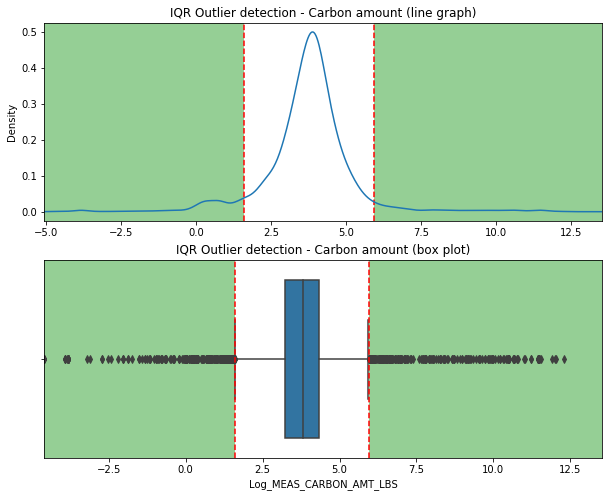

In [131]:
i = 'Log_MEAS_CARBON_AMT_LBS'

plt.figure(figsize=(10,8))
plt.subplot(211)
plt.xlim(erfp_df[i].min()*1.1, erfp_df[i].max()*1.1)
plt.axvline(x=LB, color='r', ls = '--')
plt.axvspan(xmin=LB, xmax=erfp_df[i].min()*1.1, facecolor='#2ca02c', alpha=0.5)
plt.axvline(x=UB, color='r', ls = '--')
plt.axvspan(xmin=UB, xmax=erfp_df[i].max()*1.1, facecolor='#2ca02c', alpha=0.5)
plt.title("IQR Outlier detection - Carbon amount (line graph)") 

ax = erfp_df[i].plot(kind='kde')

plt.subplot(212)
plt.xlim(erfp_df[i].min(), erfp_df[i].max()*1.1)
sns.boxplot(x=erfp_df[i])
plt.axvline(x=LB, color='r', ls = '--')
plt.axvspan(xmin=LB, xmax=erfp_df[i].min()*1.1, facecolor='#2ca02c', alpha=0.5)
plt.axvline(x=UB, color='r', ls = '--')
plt.axvspan(xmin=UB, xmax=erfp_df[i].max()*1.1, facecolor='#2ca02c', alpha=0.5)
plt.title("IQR Outlier detection - Carbon amount (box plot)") 

In [106]:
i = 'Log_MEAS_CARBON_AMT_LBS'

erfp_df['Outlier'] = 0
 
erfp_df.loc[erfp_df[i] < LB, 'Outlier'] = 1
erfp_df.loc[erfp_df[i] > UB, 'Outlier'] = 1

In [107]:
erfp_df.MEAS_CARBON_AMT_LBS.mad()

337.4306708222893

In [ ]:
type(erfp_df.MEAS_ENERGY_AMT)

In [29]:
erfp_df.shape

(12577, 8)

In [79]:
erfp_df[erfp_df.Outlier != 1].MEAS_CARBON_AMT_LBS.max()

382.17

In [108]:
erfp_df[erfp_df.Outlier == 1].count()

HOTEL_ID                          158
MEAS_CARBON                       158
MEAS_CARBON_AMT                   158
MEAS_CARBON_UOM_NORMALISED        158
MEAS_CARBON_AMT_LBS               158
MEAS_CARBON_PD                    158
MAX_LATEST_DATE                   158
Log_MEAS_CARBON_AMT_LBS           158
MEAS_CARBON_AMT_LBS_Zscore        158
MEAS_CARBON_AMT_LBS_Zscore_abs    158
Outlier                           158
dtype: int64

In [109]:
import datetime as d
file = "C:\\Users\\svi02\\Documents\\Green_score\\CARBON_CERTIFIED.xlsx" 
with pd.ExcelWriter(file) as writer: 
    erfp_df[erfp_df.Outlier == 1].to_excel(writer, sheet_name='OUTLIER', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))
    erfp_df[erfp_df.Outlier == 0].to_excel(writer, sheet_name='BENCHMARK', header=True, encoding='utf-8', index=False, freeze_panes=(1,1))

In [ ]:
# OUTLIER
erfp_df[erfp_df.Outlier == 1].to_excel('C:\\Users\\svi02\\Documents\\Green_score\\carbon_outliers.xlsx', 
                sheet_name='CARBON_outlier')